# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [2]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('../data/global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


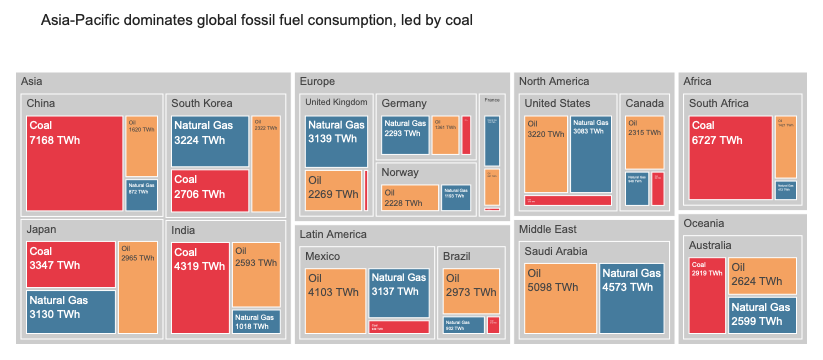

In [3]:
# Task 1 — Treemap: fossil fuel dependency by country

# Filter to fossil sources only
fossil = df[df['Source_Type'] == 'Fossil'].copy()

# CVD-safe palette for Coal / Oil / Natural Gas
fossil_colors = {
    'Coal':        '#E63946',
    'Oil':         '#F4A261',
    'Natural Gas': '#457B9D'
}

fig = px.treemap(
    fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map={
        **fossil_colors,
        '(?)': '#CCCCCC'   # grey for parent nodes
    },
    title='Asia-Pacific dominates global fossil fuel consumption, led by coal'
)

fig.update_traces(
    texttemplate='%{label}<br>%{value:.0f} TWh',
    textfont=dict(family='Arial', size=11),
    marker=dict(line=dict(width=1, color='white'))
)

fig.update_layout(
    paper_bgcolor='white',
    font=dict(family='Arial'),
    title=dict(font=dict(family='Arial', size=15, color='#222222')),
    margin=dict(t=50, l=10, r=10, b=10)
)

fig.show()


## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


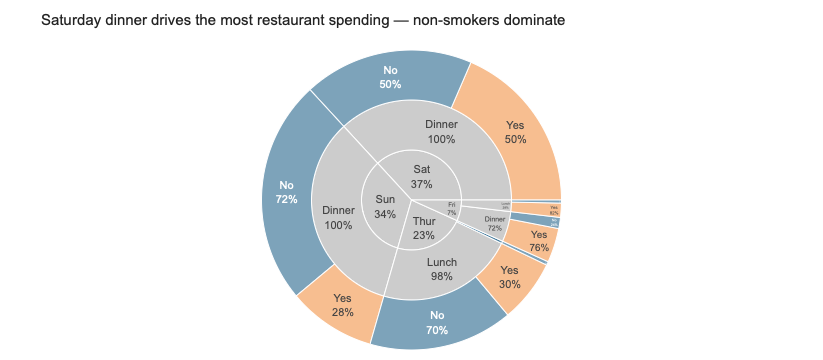

In [4]:
tips = px.data.tips()

# Aggregate total bill per group
tips_agg = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

smoker_colors = {
    'No':  '#457B9D',   # blue  = non-smoker
    'Yes': '#F4A261',   # orange = smoker
    '(?)': '#CCCCCC'    # grey for parent nodes
}

fig = px.sunburst(
    tips_agg,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map=smoker_colors,
    title='Saturday dinner drives the most restaurant spending — non-smokers dominate'
)

fig.update_traces(
    texttemplate='%{label}<br>%{percentParent:.0%}',
    textfont=dict(family='Arial', size=11),
    insidetextorientation='horizontal'
)

fig.update_layout(
    paper_bgcolor='white',
    font=dict(family='Arial'),
    title=dict(font=dict(family='Arial', size=15, color='#222222')),
    margin=dict(t=50, l=10, r=10, b=10)
)

fig.show()


## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


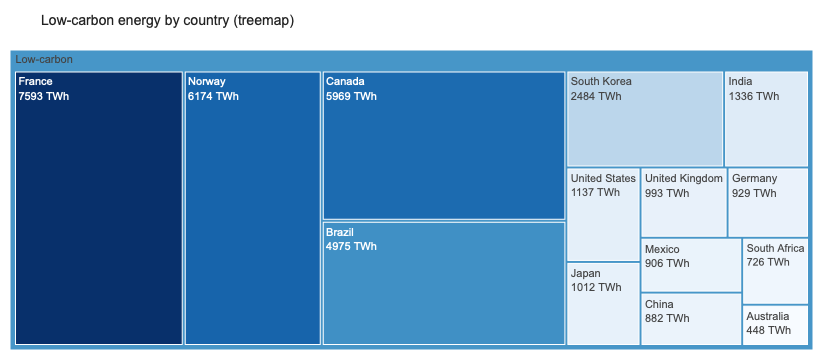

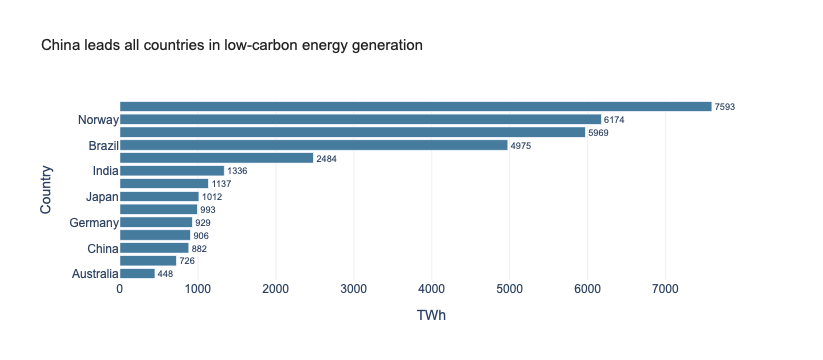

In [5]:
lowcarbon = (
    df[df['Source_Type'] == 'Low-carbon']
    .groupby('Country')['TWh']
    .sum()
    .reset_index()
    .sort_values('TWh', ascending=False)
)
lowcarbon['All'] = 'Low-carbon'  # dummy root node

# --- Treemap ---
fig_tree = px.treemap(
    lowcarbon,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues',
    title='Low-carbon energy by country (treemap)'
)

fig_tree.update_traces(
    texttemplate='%{label}<br>%{value:.0f} TWh',
    textfont=dict(family='Arial', size=11),
    marker=dict(line=dict(width=1, color='white'))
)

fig_tree.update_layout(
    paper_bgcolor='white',
    font=dict(family='Arial'),
    title=dict(font=dict(family='Arial', size=14, color='#222222')),
    coloraxis_showscale=False,
    margin=dict(t=50, l=10, r=10, b=10)
)
fig_tree.show()

# --- Bar chart ---
fig_bar = px.bar(
    lowcarbon.sort_values('TWh', ascending=True),
    x='TWh',
    y='Country',
    orientation='h',
    text='TWh',
    color_discrete_sequence=['#457B9D'],
    title='China leads all countries in low-carbon energy generation'
)

fig_bar.update_traces(
    texttemplate='%{text:.0f}',
    textposition='outside',
    marker_color='#457B9D'
)

fig_bar.update_layout(
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Arial'),
    title=dict(font=dict(family='Arial', size=15, color='#222222')),
    xaxis=dict(
        title='TWh',
        showgrid=True, gridcolor='#F0F0F0',
        showline=False
    ),
    yaxis=dict(showgrid=False, showline=False),
    margin=dict(l=120, r=80)
)
fig_bar.show()
